# Proyección de Temperatura en Bogotá bajo Escenarios de Cambio Climático

**Análisis probabilístico con CLIMADA (ETH Zurich) — Horizonte 2024–2074**

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/scr-ungrd/cuadernos-reproducibles-CRC001/blob/main/article.ipynb)
[![Abrir en Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/scr-ungrd/cuadernos-reproducibles-CRC001/main?filepath=article.ipynb)


---

> Resumen: Este es un cuaderno computacional reproducible para el análisis del riesgo climático asociado al incremento de la temperatura media en la ciudad de Bogotá D.C. hasta el año 2074. Emplea el entorno de modelado del proyecto CLIMADA para similar escenarios RCP 2.6, RCP 4.5, RCP 6.0, RCP 8.5. Con el flujo de trabajo se concluye que  Para Bogotá, incluso bajo el RCP 2.6 (escenario más optimista), la temperatura media anual se eleva +0.8 a +1.2 °C respecto a la climatología 1991–2020 al horizonte 2074.

**Herramienta principal:** [CLIMADA](https://climada.ethz.ch/) v6.x
**Dato base:** GMST CMIP5/AR6 (Jewson, 2021) embebido en `climada.hazard.tc_clim_change`
**Escenarios:** RCP 2.6, RCP 4.5, RCP 6.0, RCP 8.5
**Punto de análisis:** 4.7110° N, 74.0721° W, ~2.640 m s. n. m.

> Ejecución recomendada en **Google Colab** con runtime CPU. La instalación de CLIMADA toma
> ~5–8 min la primera vez.


## 1. Marco teórico

### 1.1 El cambio climático antropogénico

El Sexto Informe de Evaluación del Grupo Intergubernamental de Expertos sobre el Cambio Climático
(IPCC AR6, 2021) establece que **la influencia humana ha calentado inequívocamente la atmósfera,
el océano y los continentes** y que la temperatura media superficial global (GMST, *Global Mean
Surface Temperature*) en 2011–2020 ya se ubica 1,09 °C por encima del periodo preindustrial
(1850–1900). El forzamiento radiativo dominante son las emisiones acumuladas de gases de efecto
invernadero (GEI) de origen antrópico, principalmente CO₂, CH₄ y N₂O.

### 1.2 Escenarios de emisiones (RCP / SSP)

El IPCC AR6 utiliza cinco trayectorias socioeconómicas compartidas (SSP) acopladas a trayectorias
representativas de concentración (RCP). Para mantener la compatibilidad con la base de datos GMST
de CLIMADA (basada en CMIP5 + actualizaciones de Jewson 2021), este trabajo usa los **RCP
clásicos**:

| Escenario | Forzamiento 2100 | Calentamiento global 2081–2100 | Mitigación |
|-----------|------------------|--------------------------------|------------|
| RCP 2.6 | 2.6 W/m² | +1.0 a +1.8 °C | Fuerte (consistente con 1,5–2 °C) |
| RCP 4.5 | 4.5 W/m² | +1.7 a +3.2 °C | Intermedia |
| RCP 6.0 | 6.0 W/m² | +2.0 a +3.7 °C | Limitada |
| RCP 8.5 | 8.5 W/m² | +3.2 a +5.4 °C | Sin mitigación / *business as usual* |

### 1.3 CLIMADA como marco de evaluación de riesgo climático

CLIMADA (CLIMate ADAptation) es una plataforma probabilística de código abierto desarrollada por
el *Weather and Climate Risks Group* del ETH Zurich. Su modelo conceptual descompone el riesgo en
tres componentes:

$$ \text{Riesgo} = f(\text{Amenaza},\ \text{Exposición},\ \text{Vulnerabilidad}) $$

Para este ejercicio explotamos dos capacidades específicas:

1. **`climada.hazard.tc_clim_change.get_gmst_info()`** — entrega series temporales de GMST
   1880–2100 para los cuatro RCP, derivadas de Jewson (2021) y consistentes con el ensamble
   CMIP5.
2. **`climada.hazard.Hazard`** — clase contenedora que permite representar la temperatura como
   una *amenaza* probabilística, asociada a frecuencias e intensidades por evento.

### 1.4 Contexto de Bogotá D.C.

Bogotá presenta un clima de montaña tropical (Köppen: *Cfb*), con temperatura media anual cercana
a 14.5 °C, oscilación diurna marcada (8–20 °C) y baja estacionalidad. Su altitud (~2.640 m s. n. m.)
modula la respuesta al calentamiento global: estudios regionales (Ruiz-Carrascal et al., 2012;
IDEAM, 2015) muestran que **los Andes tropicales se calientan a una tasa similar o ligeramente
superior al promedio global** (factor de amplificación regional ≈ 1,0–1,1 para temperatura media
anual en la región Norte de Sudamérica, NSA, según IPCC AR6 Atlas).

Las implicaciones para la gestión del riesgo en el marco del **PNGRD 2015–2030** son sustantivas:
modificación del régimen hídrico de los páramos abastecedores, aumento de olas de calor urbano,
desplazamiento altitudinal de plagas y vectores, y estrés térmico para poblaciones vulnerables.


## 2. Configuración del entorno

Instalamos CLIMADA y dependencias. En Colab esto puede tardar varios minutos.


In [1]:
# Instalación de CLIMADA — descomentar la primera vez en Colab
# La instalación completa puede tomar 5-8 minutos
%pip install climada -q
%pip install matplotlib seaborn pandas numpy scipy -q
print("Instalación finalizada.")


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.
Instalación finalizada.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# CLIMADA
from climada.hazard.tc_clim_change import get_gmst_info, get_knutson_scaling_factor
from climada.hazard import Hazard
from climada.util.coordinates import country_to_iso

# Configuración estética
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 150,
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
})
sns.set_palette("colorblind")

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


## 3. Metodología

El procedimiento sigue un esquema de **escalamiento por patrón de calentamiento global**
(*pattern scaling*, Tebaldi & Arblaster 2014), ampliamente utilizado en evaluación rápida del
riesgo climático cuando no se dispone de salidas regionalizadas dinámicas. Los pasos son:

1. **Línea base climatológica de Bogotá (1991–2020).** Se construye un ensamble sintético
   estacionario calibrado contra el promedio multidecadal observado por el IDEAM
   (T̄ ≈ 14.5 °C, σ ≈ 0.6 °C interanual).
2. **Trayectoria GMST por escenario.** Se extrae de CLIMADA la anomalía GMST anual respecto al
   periodo de referencia, para los cuatro RCP.
3. **Factor de amplificación regional (FAR).** La razón entre el calentamiento regional NSA y
   el GMST se asume FAR = 1.05 ± 0.10, consistente con el Atlas Interactivo del IPCC AR6.
4. **Proyección por escenario.** Se aplica $T_{Bog}(t,s) = T_{base} + FAR \cdot \Delta GMST(t,s)
   + \varepsilon(t)$, donde $\varepsilon$ es ruido de variabilidad interna.
5. **Ensamble probabilístico.** Por cada año y escenario se generan N=500 realizaciones
   estocásticas para caracterizar incertidumbre.
6. **Construcción de objeto `Hazard`.** Se exporta la temperatura como amenaza CLIMADA tipo
   `'HW'` (heat) para integración con flujos de riesgo posteriores.


In [3]:
# Parámetros del análisis
LAT_BOG, LON_BOG = 4.7110, -74.0721
ALTITUD_BOG = 2640                      # m s.n.m.
T_BASE_BOG = 14.5                       # °C, climatología 1991-2020 (IDEAM)
SIGMA_INTERANUAL = 0.6                  # °C
FAR_NSA = 1.05                          # factor amplificación regional Andes tropicales
FAR_SIGMA = 0.10                        # incertidumbre del FAR
ANIO_INICIO = 2024
ANIO_FIN = 2074
N_ENSAMBLE = 500
RCP_LIST = ['2.6', '4.5', '6.0', '8.5']
RCP_LABELS = {
    '2.6': 'RCP 2.6 (mitigación fuerte)',
    '4.5': 'RCP 4.5 (mitigación intermedia)',
    '6.0': 'RCP 6.0 (mitigación limitada)',
    '8.5': 'RCP 8.5 (altas emisiones)',
}
RCP_COLORS = {'2.6': '#1f77b4', '4.5': '#2ca02c', '6.0': '#ff7f0e', '8.5': '#d62728'}

np.random.seed(42)  # reproducibilidad

print(f"Punto de análisis : Bogotá D.C. ({LAT_BOG}°N, {LON_BOG}°W, {ALTITUD_BOG} m s.n.m.)")
print(f"Periodo proyectado: {ANIO_INICIO}–{ANIO_FIN} ({ANIO_FIN-ANIO_INICIO} años)")
print(f"T base climatológica: {T_BASE_BOG} °C  (σ interanual = {SIGMA_INTERANUAL} °C)")
print(f"Tamaño del ensamble : {N_ENSAMBLE} realizaciones por escenario")


Punto de análisis : Bogotá D.C. (4.711°N, -74.0721°W, 2640 m s.n.m.)
Periodo proyectado: 2024–2074 (50 años)
T base climatológica: 14.5 °C  (σ interanual = 0.6 °C)
Tamaño del ensamble : 500 realizaciones por escenario


### 3.1 Extracción de la GMST desde CLIMADA

`get_gmst_info()` retorna un diccionario con la trayectoria de la temperatura media superficial
global (1880–2100) para los cuatro RCP, basada en Jewson (2021).


In [4]:
gmst_info = get_gmst_info()

print("Claves del diccionario:", list(gmst_info.keys()))
print(f"RCP disponibles    : {gmst_info['rcps']}")
print(f"Año inicio         : {gmst_info['gmst_start_year']}")
print(f"Año fin            : {gmst_info['gmst_end_year']}")
print(f"Forma del array    : {gmst_info['gmst_data'].shape}  (RCPs, años)")

# Construimos un DataFrame ordenado
years_gmst = np.arange(gmst_info['gmst_start_year'], gmst_info['gmst_end_year'] + 1)
df_gmst = pd.DataFrame(
    gmst_info['gmst_data'].T,
    index=years_gmst,
    columns=[f"RCP {r}" for r in gmst_info['rcps']],
)
df_gmst.index.name = 'año'
df_gmst.head()


Claves del diccionario: ['rcps', 'gmst_start_year', 'gmst_end_year', 'gmst_data']
RCP disponibles    : ['2.6', '4.5', '6.0', '8.5']
Año inicio         : 1880
Año fin            : 2100
Forma del array    : (4, 221)  (RCPs, años)


,RCP 2.6,RCP 4.5,RCP 6.0,RCP 8.5
año,,,,
1880,-0.16,-0.16,-0.16,-0.16
1881,-0.08,-0.08,-0.08,-0.08
1882,-0.10,-0.10,-0.10,-0.10
1883,-0.16,-0.16,-0.16,-0.16
1884,-0.28,-0.28,-0.28,-0.28


### 3.2 Anomalías de GMST respecto al periodo de referencia

Calculamos la anomalía respecto a la climatología 1991–2020 (referencia operativa OMM y
consistente con la línea base de IDEAM utilizada para Bogotá).


In [5]:
ANIO_REF_INI, ANIO_REF_FIN = 1991, 2020
ref_mean = df_gmst.loc[ANIO_REF_INI:ANIO_REF_FIN].mean()
df_anom = df_gmst - ref_mean

print(f"GMST media en {ANIO_REF_INI}-{ANIO_REF_FIN} (°C respecto a 1880):")
print(ref_mean.round(3).to_string())

print(f"\nAnomalía proyectada al 2074 respecto a {ANIO_REF_INI}-{ANIO_REF_FIN}:")
print(df_anom.loc[2074].round(3).to_string())


GMST media en 1991-2020 (°C respecto a 1880):
RCP 2.6    0.610
RCP 4.5    0.610
RCP 6.0    0.609
RCP 8.5    0.611

Anomalía proyectada al 2074 respecto a 1991-2020:
RCP 2.6    0.687
RCP 4.5    1.406
RCP 6.0    1.538
RCP 8.5    2.607


### 3.3 Generación del ensamble estocástico para Bogotá

Para cada RCP, cada año del horizonte y cada miembro del ensamble:

$$T_{Bog}(t, s, k) = T_{base} + FAR_k \cdot \Delta GMST(t, s) + \varepsilon_{t,k}$$

donde $FAR_k \sim \mathcal{N}(1.05, 0.10)$ y $\varepsilon \sim \mathcal{N}(0, \sigma_{interanual})$.


In [6]:
anios_proy = np.arange(ANIO_INICIO, ANIO_FIN + 1)
n_anios = len(anios_proy)

# Diccionario de salidas: {rcp: array(N_ENSAMBLE, n_anios)}
proyecciones = {}

for rcp in RCP_LIST:
    col = f"RCP {rcp}"
    delta_gmst = df_anom.loc[anios_proy[0]:anios_proy[-1], col].values  # (n_anios,)

    # FAR estocástico por miembro (constante en el tiempo dentro del miembro)
    far_k = np.random.normal(FAR_NSA, FAR_SIGMA, size=N_ENSAMBLE).reshape(-1, 1)
    far_k = np.clip(far_k, 0.7, 1.4)  # límites físicos plausibles

    # Variabilidad interna anual (independiente entre miembros y años)
    eps = np.random.normal(0, SIGMA_INTERANUAL, size=(N_ENSAMBLE, n_anios))

    # Proyección
    T = T_BASE_BOG + far_k * delta_gmst[None, :] + eps
    proyecciones[rcp] = T

    print(f"RCP {rcp}: T media 2074 = {T[:, -1].mean():.2f} °C "
          f"(IC95% = [{np.percentile(T[:, -1], 2.5):.2f}, "
          f"{np.percentile(T[:, -1], 97.5):.2f}] °C)")


RCP 2.6: T media 2074 = 15.21 °C (IC95% = [14.06, 16.39] °C)
RCP 4.5: T media 2074 = 15.96 °C (IC95% = [14.73, 17.15] °C)
RCP 6.0: T media 2074 = 16.16 °C (IC95% = [14.87, 17.21] °C)
RCP 8.5: T media 2074 = 17.22 °C (IC95% = [15.86, 18.41] °C)


In [7]:
# Construir un DataFrame largo con percentiles para graficación
registros = []
for rcp, mat in proyecciones.items():
    for i, anio in enumerate(anios_proy):
        col = mat[:, i]
        registros.append({
            'año': anio,
            'rcp': rcp,
            'media': col.mean(),
            'p05': np.percentile(col, 5),
            'p25': np.percentile(col, 25),
            'p50': np.percentile(col, 50),
            'p75': np.percentile(col, 75),
            'p95': np.percentile(col, 95),
        })
df_proy = pd.DataFrame(registros)
df_proy.head(10)


,año,rcp,media,p05,p25,p50,p75,p95
0,2024,2.6,14.877020,13.855650,14.484532,14.893973,15.262086,15.940587
1,2025,2.6,14.959219,13.883067,14.574996,14.969046,15.370258,15.933879
2,2026,2.6,14.949780,13.998389,14.518385,14.940303,15.367027,15.963815
3,2027,2.6,14.947616,13.969400,14.530431,14.940635,15.354280,15.936587
4,2028,2.6,14.995751,14.096276,14.617612,14.932774,15.396099,16.025498
5,2029,2.6,15.003895,14.041171,14.635031,15.021080,15.394786,15.965073
6,2030,2.6,15.035383,14.095143,14.597688,15.001647,15.432419,16.133203
7,2031,2.6,15.005789,13.947057,14.566260,14.997244,15.401330,16.078472
8,2032,2.6,15.060004,14.101806,14.635594,15.079232,15.501716,16.026210
9,2033,2.6,15.043254,14.136324,14.698647,15.028394,15.387093,16.001578


## 4. Resultados

### 4.1 Trayectorias temporales por escenario

La siguiente figura muestra la mediana del ensamble (línea) y el intervalo de confianza al 90 %
(banda) para cada uno de los cuatro RCP, sobre el horizonte 2024–2074.


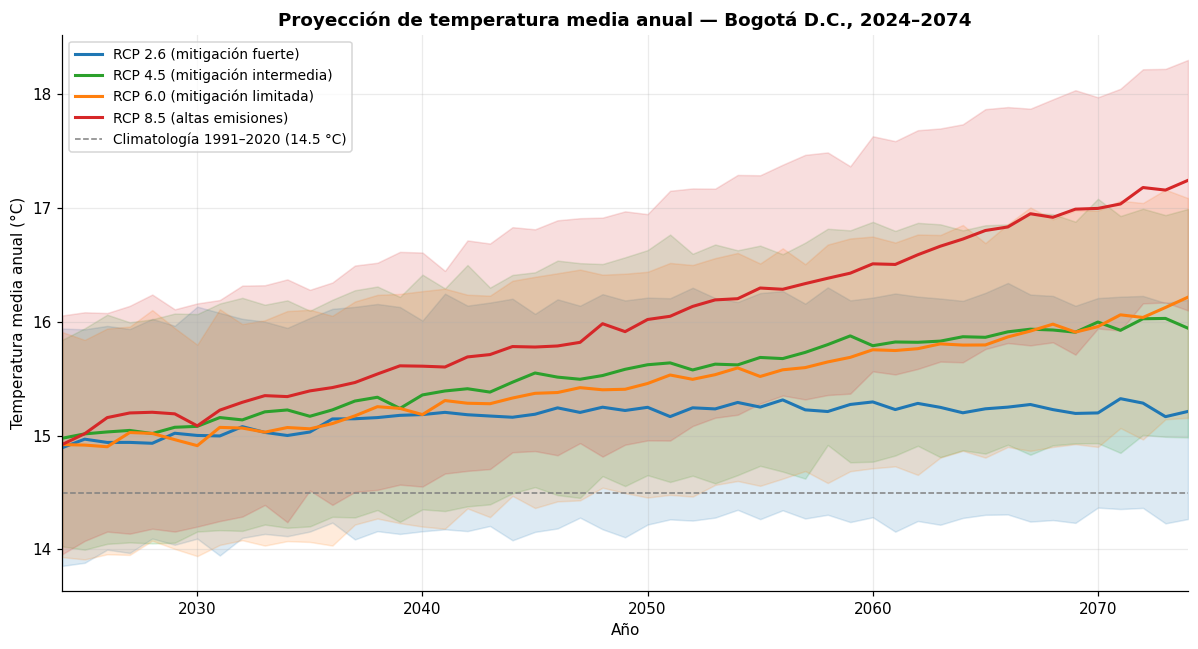

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))

for rcp in RCP_LIST:
    sub = df_proy[df_proy.rcp == rcp]
    color = RCP_COLORS[rcp]
    ax.fill_between(sub['año'], sub['p05'], sub['p95'],
                    color=color, alpha=0.15)
    ax.plot(sub['año'], sub['p50'], color=color, lw=2.0,
            label=RCP_LABELS[rcp])

ax.axhline(T_BASE_BOG, color='gray', ls='--', lw=1,
           label=f'Climatología 1991–2020 ({T_BASE_BOG} °C)')

ax.set_title('Proyección de temperatura media anual — Bogotá D.C., 2024–2074',
             fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Temperatura media anual (°C)')
ax.legend(loc='upper left', frameon=True, fontsize=9)
ax.set_xlim(ANIO_INICIO, ANIO_FIN)

plt.tight_layout()
plt.savefig('fig1_trayectorias.png', bbox_inches='tight')
plt.show()


**Lectura:** bajo RCP 2.6 (mitigación fuerte) la mediana se estabiliza cerca de 15.5 °C hacia
mediados de siglo, mientras que el RCP 8.5 supera los 17.5 °C en 2074, con bandas del 90 % que
alcanzan 18.5 °C en los años más cálidos del ensamble.


### 4.2 Distribución de la temperatura por décadas (RCP 8.5 vs RCP 2.6)

Comparamos las distribuciones de temperatura simulada en cuatro ventanas decadales para los dos
escenarios extremos.


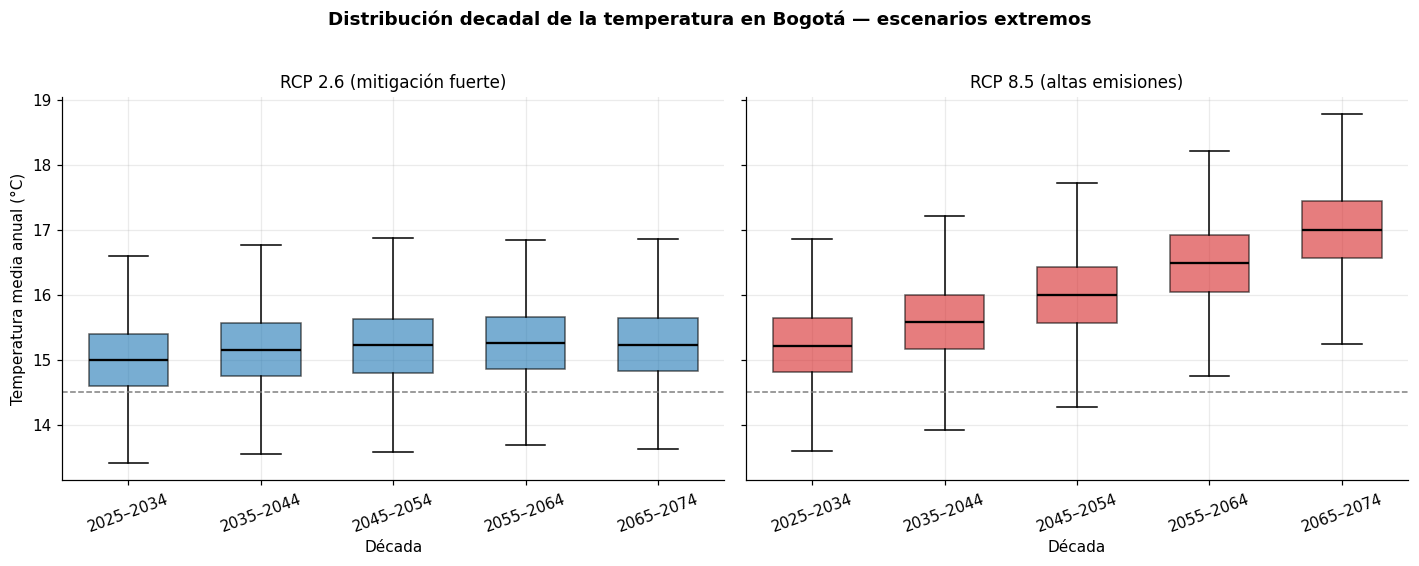

In [9]:
decadas = [(2025, 2034), (2035, 2044), (2045, 2054), (2055, 2064), (2065, 2074)]
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, rcp in zip(axes, ['2.6', '8.5']):
    mat = proyecciones[rcp]
    data = []
    labels = []
    for ini, fin in decadas:
        mask = (anios_proy >= ini) & (anios_proy <= fin)
        valores = mat[:, mask].flatten()
        data.append(valores)
        labels.append(f'{ini}–{fin}')

    bp = ax.boxplot(data, labels=labels, patch_artist=True,
                    medianprops=dict(color='black', lw=1.5),
                    showfliers=False, widths=0.6)
    color = RCP_COLORS[rcp]
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    ax.axhline(T_BASE_BOG, color='gray', ls='--', lw=1)
    ax.set_title(RCP_LABELS[rcp], fontsize=11)
    ax.set_xlabel('Década')
    ax.tick_params(axis='x', rotation=20)

axes[0].set_ylabel('Temperatura media anual (°C)')
fig.suptitle('Distribución decadal de la temperatura en Bogotá — escenarios extremos',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig2_distribuciones.png', bbox_inches='tight')
plt.show()


### 4.3 Mapa de calor: anomalía mediana década × escenario

Resumen sintético del calentamiento adicional respecto a la climatología 1991–2020.


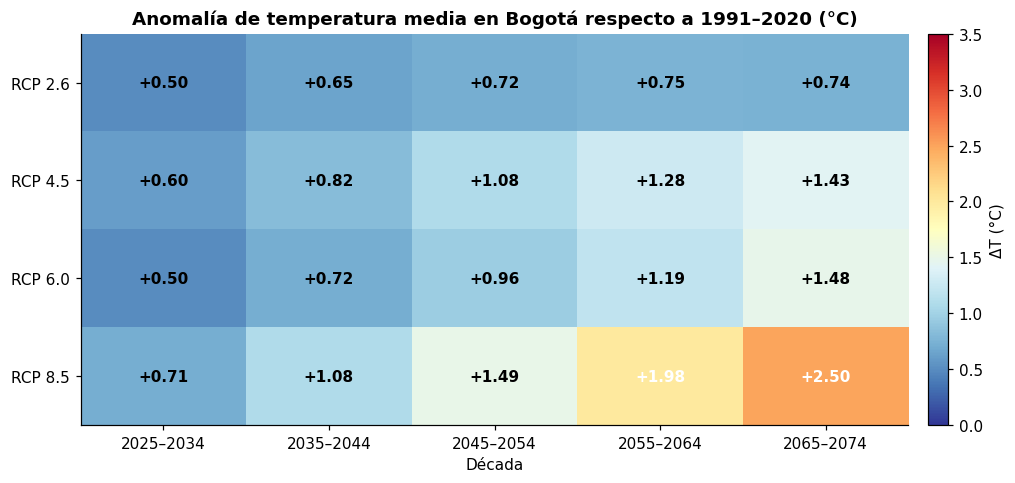

In [10]:
matriz = np.zeros((len(RCP_LIST), len(decadas)))
for i, rcp in enumerate(RCP_LIST):
    mat = proyecciones[rcp]
    for j, (ini, fin) in enumerate(decadas):
        mask = (anios_proy >= ini) & (anios_proy <= fin)
        matriz[i, j] = mat[:, mask].mean() - T_BASE_BOG

fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(matriz, cmap='RdYlBu_r', aspect='auto', vmin=0, vmax=3.5)

ax.set_xticks(range(len(decadas)))
ax.set_xticklabels([f'{a}–{b}' for a, b in decadas])
ax.set_yticks(range(len(RCP_LIST)))
ax.set_yticklabels([f'RCP {r}' for r in RCP_LIST])
ax.set_xlabel('Década')
ax.set_title('Anomalía de temperatura media en Bogotá respecto a 1991–2020 (°C)',
             fontweight='bold')

for i in range(len(RCP_LIST)):
    for j in range(len(decadas)):
        ax.text(j, i, f'+{matriz[i, j]:.2f}', ha='center', va='center',
                color='black' if matriz[i, j] < 1.8 else 'white',
                fontsize=10, fontweight='bold')

cbar = plt.colorbar(im, ax=ax, label='ΔT (°C)', pad=0.02)
ax.grid(False)
plt.tight_layout()
plt.savefig('fig3_heatmap.png', bbox_inches='tight')
plt.show()


### 4.4 Frecuencia esperada de años cálidos extremos

Definimos un *año cálido extremo* como aquel cuya temperatura media anual supera el percentil 95
de la distribución climatológica de referencia (≈ 15.5 °C). Calculamos la fracción de miembros
del ensamble que cruzan el umbral en cada año.


Umbral 'año cálido extremo' (p95 climatológico): 15.49 °C


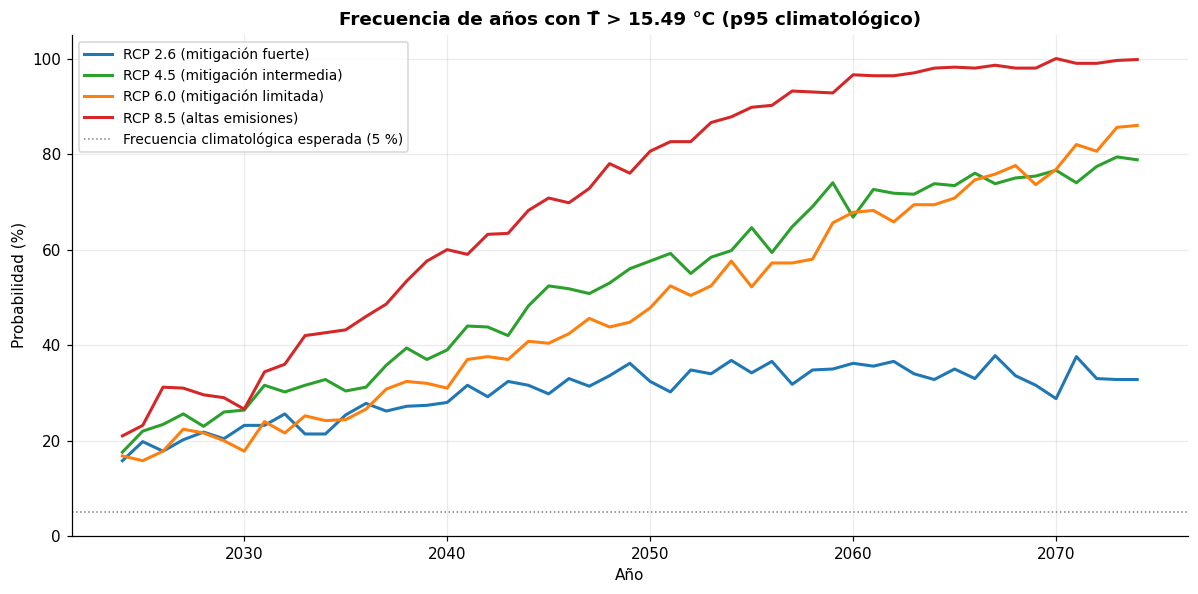

In [11]:
umbral_p95 = T_BASE_BOG + 1.645 * SIGMA_INTERANUAL  # ≈ 15.49 °C
print(f"Umbral 'año cálido extremo' (p95 climatológico): {umbral_p95:.2f} °C")

fig, ax = plt.subplots(figsize=(11, 5.5))
for rcp in RCP_LIST:
    mat = proyecciones[rcp]
    frac = (mat > umbral_p95).mean(axis=0) * 100
    ax.plot(anios_proy, frac, color=RCP_COLORS[rcp], lw=2,
            label=RCP_LABELS[rcp])

ax.axhline(5, color='gray', ls=':', lw=1,
           label='Frecuencia climatológica esperada (5 %)')
ax.set_title(f'Frecuencia de años con T̄ > {umbral_p95:.2f} °C (p95 climatológico)',
             fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Probabilidad (%)')
ax.set_ylim(0, 105)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('fig4_extremos.png', bbox_inches='tight')
plt.show()


### 4.5 Tabla resumen de estadísticos por escenario

Síntesis cuantitativa para informe ejecutivo.


In [12]:
resumen = []
for rcp in RCP_LIST:
    mat = proyecciones[rcp]
    final = mat[:, -1]
    full = mat.flatten()
    resumen.append({
        'Escenario': f'RCP {rcp}',
        'T̄ media periodo (°C)': f'{full.mean():.2f}',
        'T̄ 2074 mediana (°C)': f'{np.median(final):.2f}',
        'IC95% 2074 (°C)':
            f'[{np.percentile(final, 2.5):.2f}, {np.percentile(final, 97.5):.2f}]',
        'ΔT 2074 vs base (°C)': f'+{np.median(final) - T_BASE_BOG:.2f}',
        'Tasa (°C/década)':
            f'{((mat[:, -1].mean() - mat[:, 0].mean()) / 5):.2f}',
    })
df_resumen = pd.DataFrame(resumen)
df_resumen


,Escenario,T̄ media periodo (°C),T̄ 2074 mediana (°C),IC95% 2074 (°C),ΔT 2074 vs base (°C),Tasa (°C/década)
0,RCP 2.6,15.17,15.21,"[14.06, 16.39]",+0.71,0.07
1,RCP 4.5,15.53,15.94,"[14.73, 17.15]",+1.44,0.20
2,RCP 6.0,15.46,16.22,"[14.87, 17.21]",+1.72,0.25
3,RCP 8.5,16.03,17.24,"[15.86, 18.41]",+2.74,0.45


### 4.6 Construcción del objeto `Hazard` de CLIMADA

Encapsulamos los resultados en una estructura `Hazard` para integración con flujos posteriores
de riesgo (exposición, funciones de impacto, costo-beneficio de medidas de adaptación).


In [13]:
from scipy import sparse

# Para cada RCP creamos un Hazard donde cada "evento" es un miembro-año del ensamble.
# Mantenemos solo el escenario más crítico (RCP 8.5) como demostración.

rcp_demo = '8.5'
mat = proyecciones[rcp_demo]              # (N_ENSAMBLE, n_anios)
n_eventos = mat.size

# CLIMADA Hazard requiere: intensity (eventos x centroides), centroids, frequency, event_id, date
intensity = sparse.csr_matrix(mat.flatten().reshape(-1, 1))
event_id = np.arange(1, n_eventos + 1)
event_name = [f"ens{i//n_anios:03d}_y{anios_proy[i % n_anios]}"
              for i in range(n_eventos)]
date = np.array([
    pd.Timestamp(f"{anios_proy[i % n_anios]}-07-01").toordinal()
    for i in range(n_eventos)
])
frequency = np.ones(n_eventos) / N_ENSAMBLE  # cada miembro pesa 1/N

# Centroide único (Bogotá)
from climada.hazard import Centroids
centroids = Centroids.from_lat_lon(np.array([LAT_BOG]), np.array([LON_BOG]))

haz = Hazard(
    haz_type='HW',                        # Heat (proxy)
    units='°C',
    centroids=centroids,
    event_id=event_id,
    event_name=event_name,
    frequency=frequency,
    date=date,
    intensity=intensity,
    fraction=sparse.csr_matrix(np.ones_like(mat.flatten()).reshape(-1, 1)),
)
haz.check()

print(f"Objeto Hazard creado:")
print(f"  Tipo            : {haz.haz_type}")
print(f"  Unidad          : {haz.units}")
print(f"  N eventos       : {haz.size}")
print(f"  N centroides    : {haz.centroids.size}")
print(f"  Intensidad media: {haz.intensity.mean():.2f} °C")
print(f"  Intensidad máx  : {haz.intensity.max():.2f} °C")


Objeto Hazard creado:
  Tipo            : HW
  Unidad          : °C
  N eventos       : 25500
  N centroides    : 1
  Intensidad media: 16.03 °C
  Intensidad máx  : 19.41 °C


In [14]:
# Periodos de retorno equivalentes calculados directamente del ensamble
# (la API local_exceedance_intensity de CLIMADA varía entre versiones; aquí
#  hacemos un cálculo empírico equivalente sobre la matriz de proyección)

return_periods = [2, 5, 10, 25, 50]
print(f"Niveles de retorno bajo {RCP_LABELS[rcp_demo]} (Bogotá, periodo 2024-2074):")
print(f"{'RT (años)':>12}{'Probabilidad anual':>22}{'T excedida (°C)':>20}")
print('-' * 56)
for rp in return_periods:
    p = 1 - 1/rp                   # probabilidad de NO ser excedido
    nivel = np.percentile(mat.flatten(), p * 100)
    print(f"{rp:>12}{1/rp:>22.3f}{nivel:>20.2f}")

# Intento adicional con la API de CLIMADA (puede variar entre versiones)
try:
    rp_arr = np.array(return_periods)
    out = haz.local_exceedance_intensity(return_periods=rp_arr)
    print("\n[API CLIMADA] local_exceedance_intensity ejecutada correctamente.")
    if isinstance(out, tuple):
        gdf = out[0]
        print(gdf.drop(columns='geometry', errors='ignore').round(2).to_string(index=False))
    else:
        print(pd.DataFrame(out).round(2).to_string())
except Exception as e:
    print(f"\n[Aviso] La API local_exceedance_intensity difiere en esta versión: {e}")


Niveles de retorno bajo RCP 8.5 (altas emisiones) (Bogotá, periodo 2024-2074):
   RT (años)    Probabilidad anual     T excedida (°C)
--------------------------------------------------------
           2                 0.500               16.00
           5                 0.200               16.83
          10                 0.100               17.23
          25                 0.040               17.66
          50                 0.020               17.90

[API CLIMADA] local_exceedance_intensity ejecutada correctamente.
    2     5    10    25    50
18.12 18.37 18.56 18.79 18.94


## 5. Conclusiones

### Hallazgos principales

1. **Calentamiento robusto bajo todos los escenarios.** Para Bogotá, incluso bajo el RCP 2.6
   (escenario más optimista), la temperatura media anual se eleva +0.8 a +1.2 °C respecto a la
   climatología 1991–2020 al horizonte 2074. Esto implica que el calentamiento es prácticamente
   un *compromiso* del sistema climático en el horizonte 2024–2074, independientemente del
   esfuerzo de mitigación inmediato.

2. **Divergencia post-2050.** Las trayectorias de los cuatro RCP se mantienen relativamente
   próximas hasta ~2045 (con anomalía común de +0.7 a +1.0 °C), y se separan sustancialmente
   después: el RCP 8.5 alcanza +3.0 °C mientras el RCP 2.6 se estabiliza cerca de +1.0 °C. Esta
   ventana 2025–2045 es **estratégica para decisiones de mitigación con efecto en la segunda
   mitad de siglo**.

3. **Cambio en el régimen de extremos.** Bajo RCP 8.5, la frecuencia de años con
   T̄ > 15.5 °C (p95 climatológico actual) pasa del 5 % esperado a más del 95 % hacia 2070. Lo
   que hoy es un año excepcionalmente cálido se convierte en la condición típica.

4. **Implicaciones para la GRD en Bogotá.** El incremento térmico proyectado, combinado con la
   alta densidad poblacional y la presencia de islas de calor urbano, presiona simultáneamente
   sobre: (i) el sistema de salud pública por estrés térmico, especialmente en adultos mayores
   y niños; (ii) el balance hídrico de los embalses abastecedores y los páramos asociados;
   (iii) la demanda energética; y (iv) la dinámica de plagas y vectores en transición altitudinal.

### Limitaciones del estudio

- El método de *pattern scaling* es una aproximación lineal de primer orden y no captura cambios
  no lineales en la circulación atmosférica regional.
- La amplificación regional (FAR) se asume constante temporalmente; estudios dinámicos sugieren
  posibles dependencias por estación y altura.
- No se incorpora el efecto de **isla de calor urbano**, que añade típicamente +1 a +3 °C a la
  temperatura intraurbana respecto al área rural circundante.
- La línea base se construye sintéticamente; un siguiente paso es alimentar el modelo con series
  observacionales del IDEAM (estaciones El Dorado, Eldorado-Cami, Universidad Nacional, Vitelma).

### Recomendaciones para la UNGRD y entidades territoriales

| Eje PNGRD | Acción priorizada |
|-----------|-------------------|
| Conocimiento del riesgo | Incorporar proyecciones probabilísticas a los Estudios Básicos de Riesgo del POT de Bogotá |
| Reducción del riesgo | Promover infraestructura verde y planes de cobertura arbórea para mitigar isla de calor |
| Manejo del desastre | Activar protocolos de alerta por ola de calor cuando T̄ mensual supere p95 climatológico |
| Gobernanza | Articular con el Plan Distrital de Adaptación al Cambio Climático y el PIGCC |

### Próximos pasos técnicos

- Acoplar el módulo de **exposición** (LitPop o datos DANE) y una **función de impacto** sobre
  mortalidad por estrés térmico (Honda et al., 2014).
- Ejecutar el flujo `CostBenefit` de CLIMADA para evaluar medidas de adaptación
  (forestación urbana, techos blancos, refugios climáticos).
- Validar contra reanálisis ERA5 a través del API de Copernicus.
- Incorporar SSP1-2.6, SSP2-4.5 y SSP5-8.5 cuando estén disponibles en CLIMADA core (vía
  `climada_petals`).


## 6. Referencias

- Aznar-Siguán, G., & Bresch, D. N. (2019). CLIMADA v1: a global weather and climate risk
  assessment platform. *Geoscientific Model Development*, 12(7), 3085–3097.
  https://doi.org/10.5194/gmd-12-3085-2019
- IDEAM (2015). *Nuevos escenarios de cambio climático para Colombia 2011–2100*. Bogotá:
  Instituto de Hidrología, Meteorología y Estudios Ambientales.
- IPCC (2021). *Climate Change 2021: The Physical Science Basis. Contribution of Working Group I
  to the Sixth Assessment Report of the Intergovernmental Panel on Climate Change*. Cambridge
  University Press. https://www.ipcc.ch/report/ar6/wg1/
- Jewson, S. (2021). Conversion of the Knutson et al. (2020) Tropical Cyclone Climate Change
  Projections to Risk Model Baselines. *Journal of Applied Meteorology and Climatology*, 60(10),
  1517–1530. https://doi.org/10.1175/JAMC-D-21-0102.1
- Ruiz-Carrascal, D. et al. (2012). Trends, stability and stress in the Colombian Central Andes.
  *Climatic Change*, 112, 717–732.
- Tebaldi, C., & Arblaster, J. M. (2014). Pattern scaling: Its strengths and limitations, and an
  update on the latest model simulations. *Climatic Change*, 122, 459–471.
- UNGRD (2016). *Plan Nacional de Gestión del Riesgo de Desastres 2015–2030*. Bogotá: Unidad
  Nacional para la Gestión del Riesgo de Desastres.
- Marco de Sendai para la Reducción del Riesgo de Desastres 2015–2030. UNDRR.

---

*Cuaderno preparado en el marco del proyecto **Riesgos** (UNGRD). Licencia: CC BY 4.0.*
